<a href="https://colab.research.google.com/github/Bobby9800/STATSANDSCANS/blob/main/Car_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor
import shap
from google.colab import files  # For downloading files in Colab
import warnings
warnings.filterwarnings('ignore')

# Set plot style for visuals
sns.set(style="whitegrid")

In [2]:
#Load data
df = pd.read_csv('used_cars.csv')

In [3]:
#initial data overview
print("Initial Data Shape:", df.shape)
print(df.head())
print(df.info())
print(df.describe())

Initial Data Shape: (94251, 10)
        brand       model mileage model_year engine_size     price  \
0        bmw    3 series      $0     $2,021          $0   $20,190    
1         BMW    3 Series     $0         NaN         $0   $18,499    
2  Volkswagen       golf      $0     $2,019          $0   $11,722    
3         NaN    model 3      NaN    $2,015          $0   $28,698    
4        bmw     5 Series     $0     $2,021          $0   $16,736    

  fuel_type_diesel fuel_type_petrol transmission_auto location_encoded  
0              $0               $1                $0          $20,306   
1              $0               $1                $0          $20,306   
2              $0               $1                $1          $20,306   
3              NaN              $1                $0          $19,464   
4              NaN              $0                $1          $17,734   
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94251 entries, 0 to 94250
Data columns (total 10 columns):


In [4]:
#Data Transformation and Cleaning
#remove '$', ',', '"' from numeric columns
numeric_cols = ['mileage', 'model_year', 'engine_size', 'price', 'location_encoded']
for col in numeric_cols:
    df[col] = df[col].astype(str)  # Ensure string type
    df[col] = df[col].str.replace('$', '', regex=False)
    df[col] = df[col].str.replace(',', '', regex=False)
    df[col] = df[col].str.replace('"', '', regex=False)
    df[col] = df[col].str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce')  # Convert to numeric, coerce errors to NaN

In [5]:
# Handle binary columns
binary_cols = ['fuel_type_diesel', 'fuel_type_petrol', 'transmission_auto']
for col in binary_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(0).astype(int)

In [6]:
# Handle categorical columns: brand, model
categorical_cols = ['brand', 'model']
for col in categorical_cols:
    df[col] = df[col].astype(str).str.lower().str.strip()
    df[col] = df[col].replace('nan', np.nan)

In [7]:
# Handle missing values
# Use median
for col in numeric_cols:
    if col != 'price':
        df[col].fillna(df[col].median(), inplace=True)

In [8]:
# Impute categorical with mode or 'unknown'
for col in categorical_cols:
    df[col].fillna('unknown', inplace=True)

In [9]:
# Drop rows where price is NaN
df = df.dropna(subset=['price'])


In [10]:
# Encode categoricals
le_brand = LabelEncoder()
le_model = LabelEncoder()
df['brand_encoded'] = le_brand.fit_transform(df['brand'])
df['model_encoded'] = le_model.fit_transform(df['model'])

In [11]:
df_cleaned = df.copy()

In [12]:
# Save and download cleaned dataset for Power BI
cleaned_csv_path = 'cleaned_used_cars.csv'
df_cleaned.to_csv(cleaned_csv_path, index=False)
files.download(cleaned_csv_path)  # Trigger download in Colab
print(f"\nCleaned dataset saved and downloaded as '{cleaned_csv_path}' for Power BI visualization.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Cleaned dataset saved and downloaded as 'cleaned_used_cars.csv' for Power BI visualization.


In [13]:
# Final cleaned data overview
print("\nCleaned Data Shape:", df_cleaned.shape)
print(df_cleaned.head())
print(df_cleaned.info())
print(df_cleaned.describe())


Cleaned Data Shape: (89548, 12)
        brand     model  mileage  model_year  engine_size    price  \
0         bmw  3 series      0.0      2021.0          0.0  20190.0   
1         bmw  3 series      0.0      2016.0          0.0  18499.0   
2  volkswagen      golf      0.0      2019.0          0.0  11722.0   
3     unknown   model 3      0.0      2015.0          0.0  28698.0   
4         bmw  5 series      0.0      2021.0          0.0  16736.0   

   fuel_type_diesel  fuel_type_petrol  transmission_auto  location_encoded  \
0                 0                 0                  0           20306.0   
1                 0                 0                  0           20306.0   
2                 0                 0                  0           20306.0   
3                 0                 0                  0           19464.0   
4                 0                 0                  0           17734.0   

   brand_encoded  model_encoded  
0              1              0  
1        

In [15]:
# Summary statistics
print("\nEDA Summary:")
print(df_cleaned.describe())


EDA Summary:
            mileage    model_year   engine_size         price  \
count  89548.000000  89548.000000  89548.000000  89548.000000   
mean       0.000022   2016.394760      0.014115  19273.330962   
std        0.004726      3.913297      0.117967   6504.629800   
min        0.000000   2010.000000      0.000000   3820.000000   
25%        0.000000   2013.000000      0.000000  14417.000000   
50%        0.000000   2016.000000      0.000000  18337.000000   
75%        0.000000   2020.000000      0.000000  23291.000000   
max        1.000000   2023.000000      1.000000  37884.000000   

       fuel_type_diesel  fuel_type_petrol  transmission_auto  \
count           89548.0           89548.0            89548.0   
mean                0.0               0.0                0.0   
std                 0.0               0.0                0.0   
min                 0.0               0.0                0.0   
25%                 0.0               0.0                0.0   
50%             

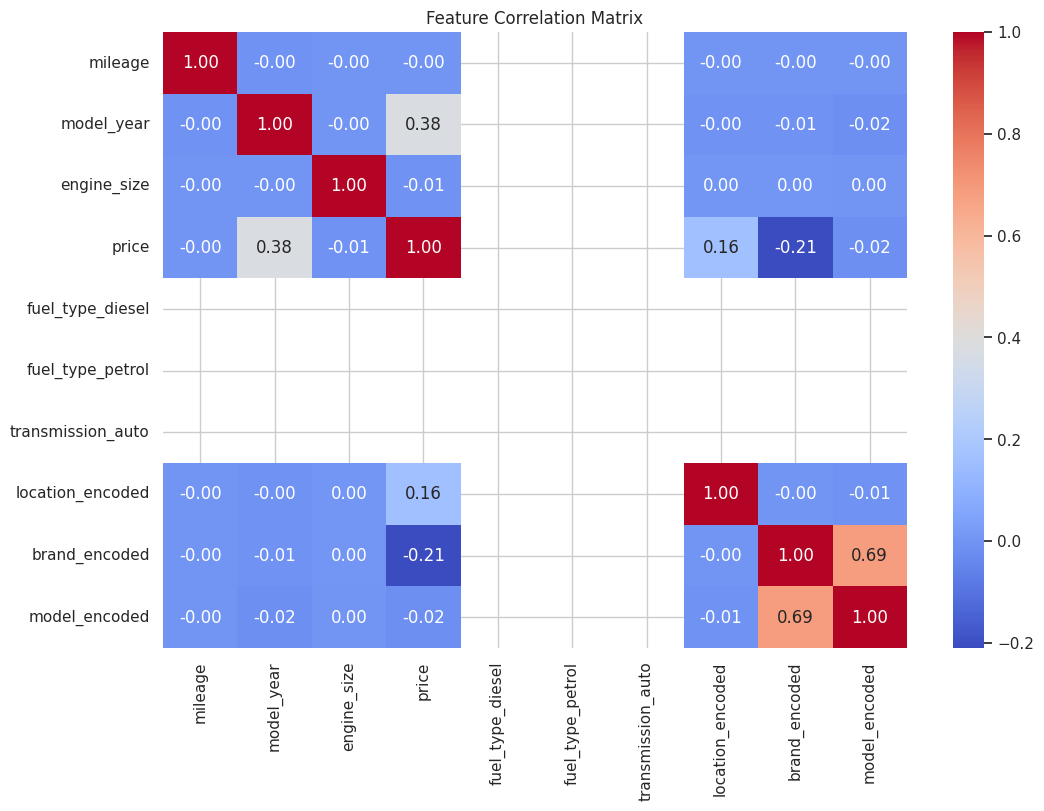

In [17]:
#Correlation Matrix
numeric_df = df_cleaned.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

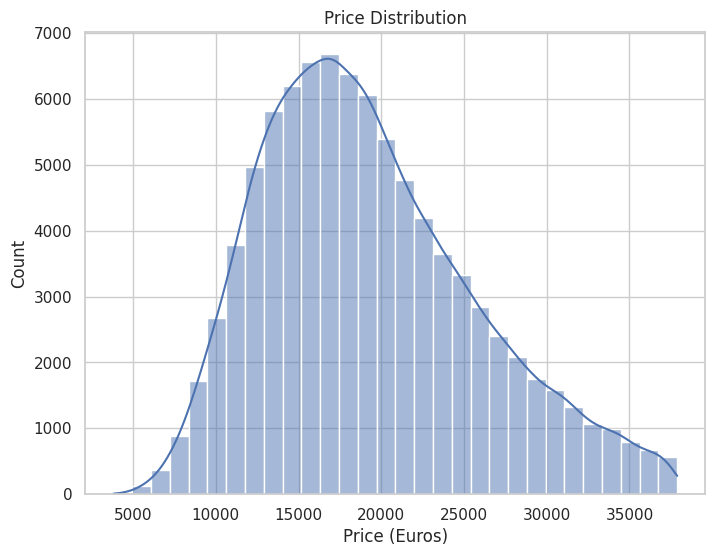

In [18]:
# Distribution of Price (target)
plt.figure(figsize=(8, 6))
sns.histplot(df_cleaned['price'], kde=True, bins=30)
plt.title('Price Distribution')
plt.xlabel('Price (Euros)')
plt.show()

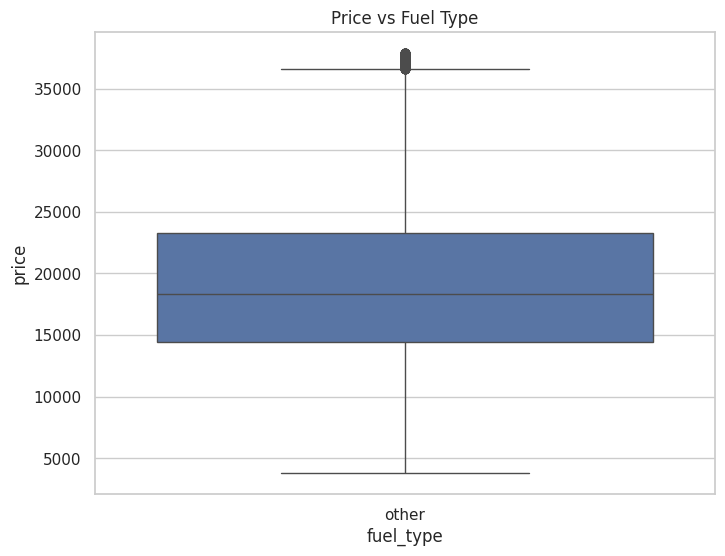

In [19]:
# Boxplot: Price vs Fuel Type (combining diesel & petrol)
df_cleaned['fuel_type'] = np.where(df_cleaned['fuel_type_diesel'] == 1, 'diesel',
                                   np.where(df_cleaned['fuel_type_petrol'] == 1, 'petrol', 'other'))
plt.figure(figsize=(8, 6))
sns.boxplot(x='fuel_type', y='price', data=df_cleaned)
plt.title('Price vs Fuel Type')
plt.show()

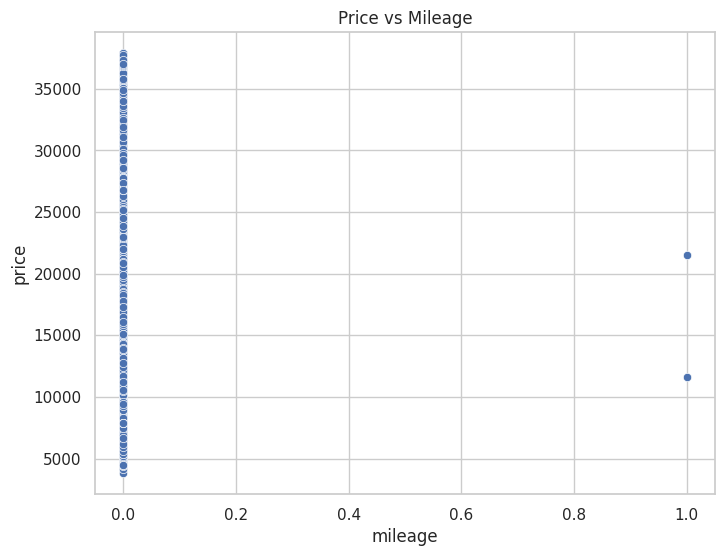

In [20]:
# Scatter: Price vs Mileage
plt.figure(figsize=(8, 6))
sns.scatterplot(x='mileage', y='price', data=df_cleaned)
plt.title('Price vs Mileage')
plt.show()

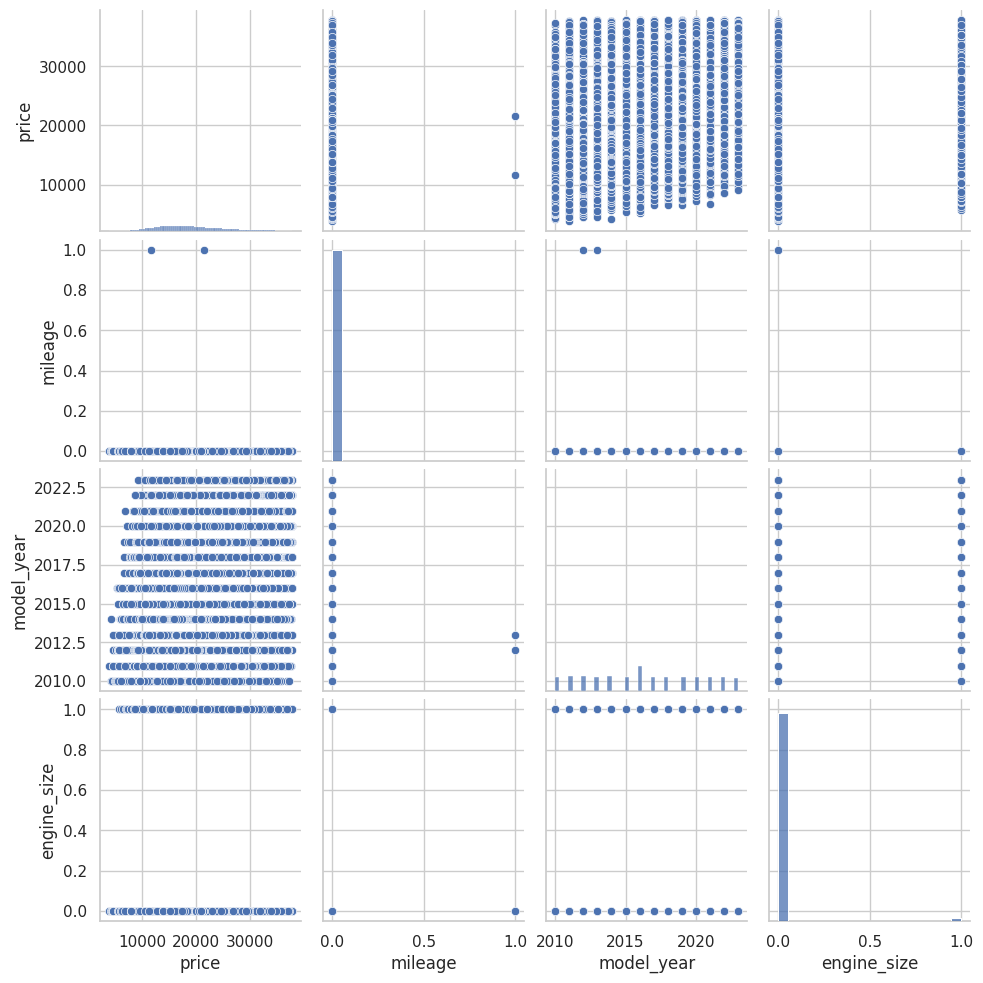

In [21]:
#Pairplot for key features
key_features = ['price', 'mileage', 'model_year', 'engine_size']
sns.pairplot(df_cleaned[key_features])
plt.show()

In [22]:
# Step 4: Data Splitting
# Features and target - exclude original categoricals from X
X = df_cleaned.drop(['price', 'fuel_type', 'brand', 'model'], axis=1)
y = df_cleaned['price']

In [23]:
# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


Train Shape: (71638, 9)
Test Shape: (17910, 9)


In [24]:
# XGBoost Regressor
# Hyperparameters
xgb_model = XGBRegressor(
    n_estimators=100,  # Default
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    objective='reg:squarederror'
)

In [25]:
# Train the model
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [26]:
# Predictions
y_pred_train = xgb_model.predict(X_train)
y_pred_test = xgb_model.predict(X_test)

In [27]:
# Save predictions
df_test = X_test.copy()
df_test['brand'] = df_cleaned.loc[X_test.index, 'brand'].values
df_test['model'] = df_cleaned.loc[X_test.index, 'model'].values
df_test['actual_price'] = y_test
df_test['predicted_price'] = y_pred_test
predictions_csv_path = 'predictions_for_powerbi.csv'
df_test.to_csv(predictions_csv_path, index=False)
files.download(predictions_csv_path)  # Trigger download in Colab
print(f"\nTest predictions saved and downloaded as '{predictions_csv_path}' for Power BI visualization.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Test predictions saved and downloaded as 'predictions_for_powerbi.csv' for Power BI visualization.


In [28]:
#  Model Evaluation
r2 = r2_score(y_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
print("\nTest R²:", r2)
print("Test RMSE:", rmse)


Test R²: 0.4571659547251513
Test RMSE: 4783.6952109848935


In [29]:
# 5-fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(xgb_model, X, y, cv=kf, scoring='r2')
cv_rmse = np.sqrt(-cross_val_score(xgb_model, X, y, cv=kf, scoring='neg_mean_squared_error'))
print("\n5-Fold CV R²:", cv_r2.mean())
print("5-Fold CV RMSE:", cv_rmse.mean())


5-Fold CV R²: 0.45823754425766366
5-Fold CV RMSE: 4787.407409851694


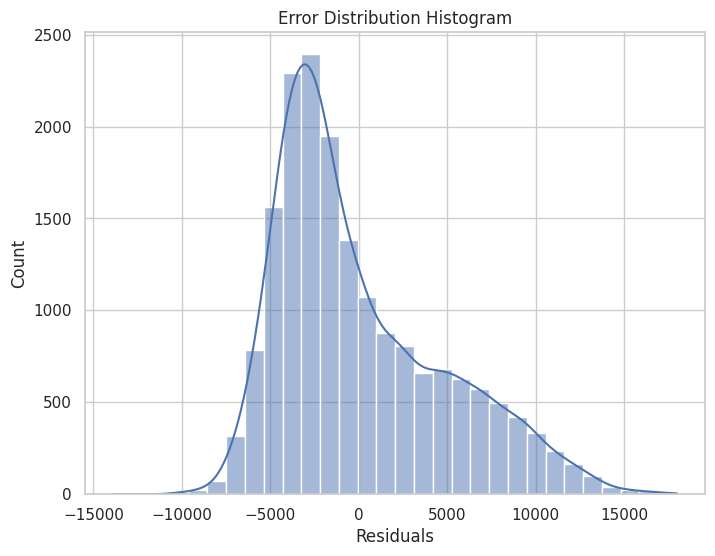

In [32]:
# Error Distribution Histogram
residuals = y_test - y_pred_test
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, bins=30)
plt.title('Error Distribution Histogram')
plt.xlabel('Residuals')
plt.show()

In [33]:
# SHAP Explainer
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test)

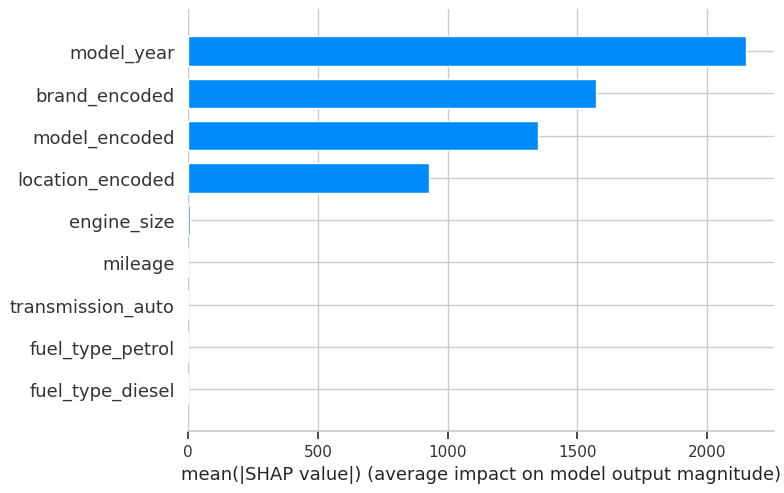

In [34]:
# SHAP Summary Plot
shap.summary_plot(shap_values, X_test, plot_type='bar')

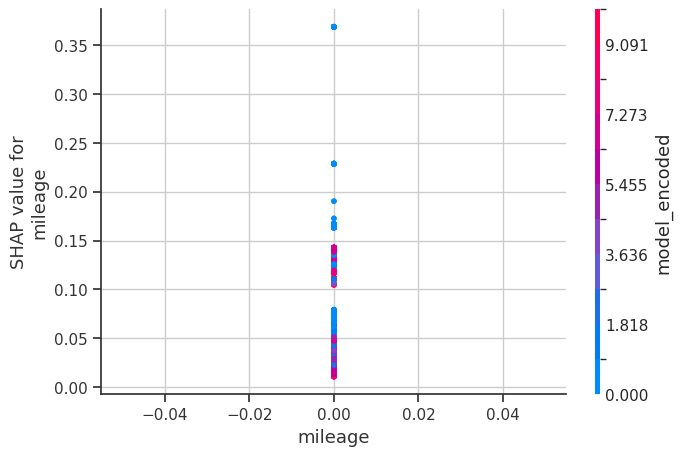

In [35]:
# SHAP Dependence Plot
shap.dependence_plot('mileage', shap_values.values, X_test)

In [36]:
# SHAP Force Plot for a single prediction
shap.initjs()
display(shap.force_plot(explainer.expected_value, shap_values.values[0], X_test.iloc[0]))

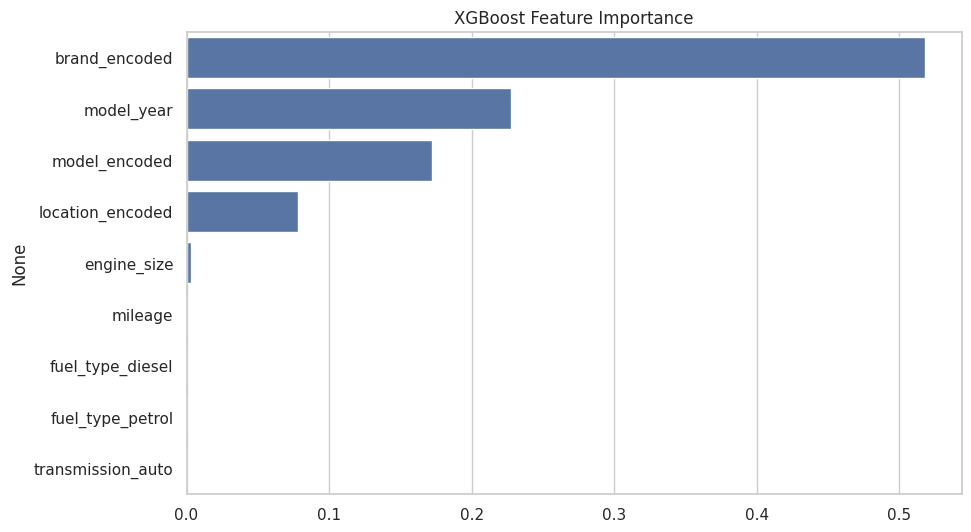

In [37]:
#Feature Importance from XGBoost
plt.figure(figsize=(10, 6))
feature_importance = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False)
sns.barplot(x=feature_importance.values, y=feature_importance.index)
plt.title('XGBoost Feature Importance')
plt.show()

In [38]:
# End of Code
print("\nCode execution complete. Model trained, evaluated, and datasets downloaded for Power BI.")


Code execution complete. Model trained, evaluated, and datasets downloaded for Power BI.
